In [8]:
pip install pandas

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.7 MB 4.8 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.7 MB 5.6 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.7 MB 6.9 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/9.7 MB 8.2 MB/s eta 0:00:01
   ----------------------------------- ---- 8.7/9.7 MB 8.9 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 9.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


ERROR: Error while checking for conflicts. Please file an issue on pip's issue tracker: https://github.com/pypa/pip/issues/new
Traceback (most recent call last):
  File "C:\Users\hp\anaconda3\Lib\site-packages\pip\_internal\commands\install.py", line 584, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\hp\anaconda3\Lib\site-packages\pip\_internal\operations\check.py", line 117, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\hp\anaconda3\Lib\site-packages\pip\_internal\operations\check.py", line 59, in create_package_set_from_installed
    package_set[name] = PackageDetails(dist.version, dependencies)
                                       ^^^^^^^^^^^^
  File "C:\Users\hp\anaconda3\Lib\site-packages\pip\_internal\metadata\importlib\_dists.py", line 168, in version
    return parse_version(sel

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
df = pd.read_csv("C:/Users/hp/Downloads/Mental_health_and_wellbeing.csv")
df.head()


,Age,Gender,Stress_Level,Hours_of_Sleep,Overall_Wellbeing_Score,Person_ID,Physical_Activity,Work_Hours_per_Day,Mental_Health_Status,Social_Interaction_Freq,Diet_Quality,Screen_Time_per_Day,Substance_Use,Has_Close_Friends,Physical_Health_Condition
0,18,Male,1,0,3,1,13,9,Mild Anxiety,Low,Excellent,8.8,Unknown,True,NaN
1,18,Male,1,1,3,2,46,9,Depression,Moderate,Fair,5.1,Alcohol,True,Hypertension
2,18,Male,1,2,3,4,30,11,Depression,Moderate,Good,7.6,Alcohol,True,NaN
3,18,Male,1,3,3,9,50,9,Mild Anxiety,High,Fair,3.9,Unknown,True,NaN
4,18,Male,1,4,3,10,20,10,Moderate Anxiety,Moderate,Very Good,6.8,Smoking,True,Hypertension


In [6]:
def categorize(score):
    if score <= 4:
        return "Poor"
    elif score <= 7:
        return "Average"
    else:
        return "Good"

df["Wellbeing_Category"] = df["Overall_Wellbeing_Score"].apply(categorize)


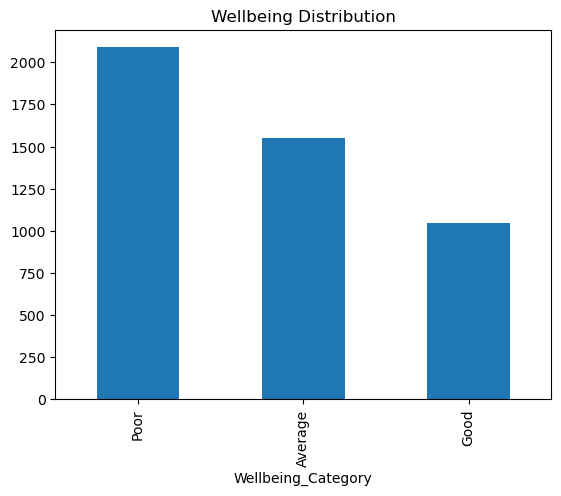

In [7]:
df["Wellbeing_Category"].value_counts().plot(kind='bar')
plt.title("Wellbeing Distribution")
plt.show()


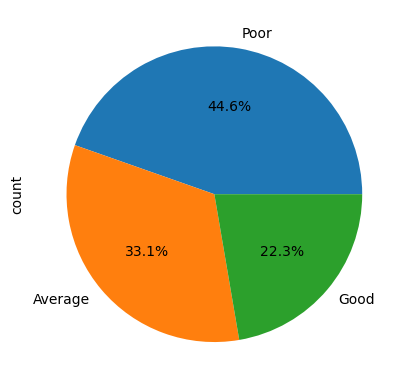

In [9]:
df["Wellbeing_Category"].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()


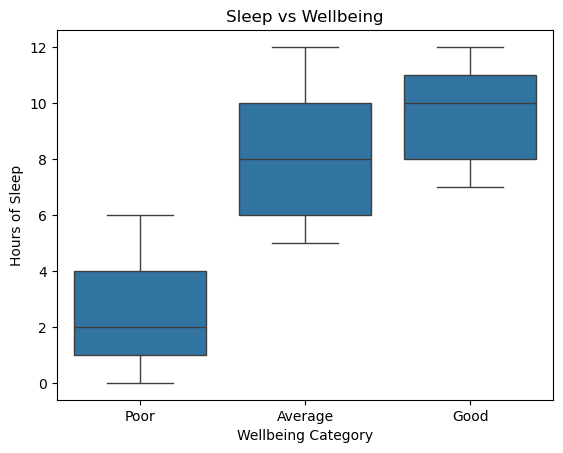

In [16]:
#Sleep vs Wellbeing
import seaborn as sns
import matplotlib.pyplot as plt
#relationship between sleep hours and wellbeing category
sns.boxplot(x="Wellbeing_Category", y="Hours_of_Sleep", data=df)

plt.title("Sleep vs Wellbeing")
plt.xlabel("Wellbeing Category")
plt.ylabel("Hours of Sleep")

plt.show()

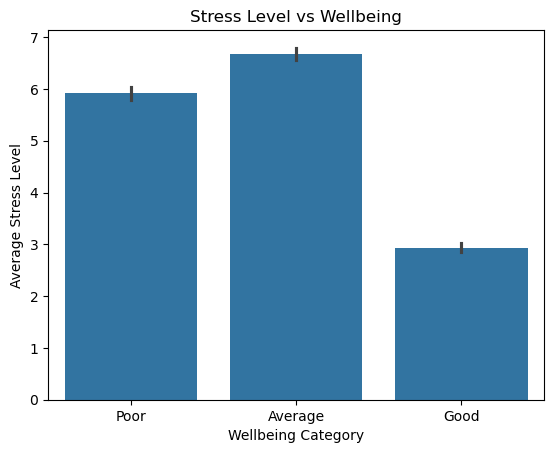

In [11]:
#Stress vs Wellbeing
sns.barplot(x="Wellbeing_Category", y="Stress_Level", data=df)

plt.title("Stress Level vs Wellbeing")
plt.xlabel("Wellbeing Category")
plt.ylabel("Average Stress Level")

plt.show()

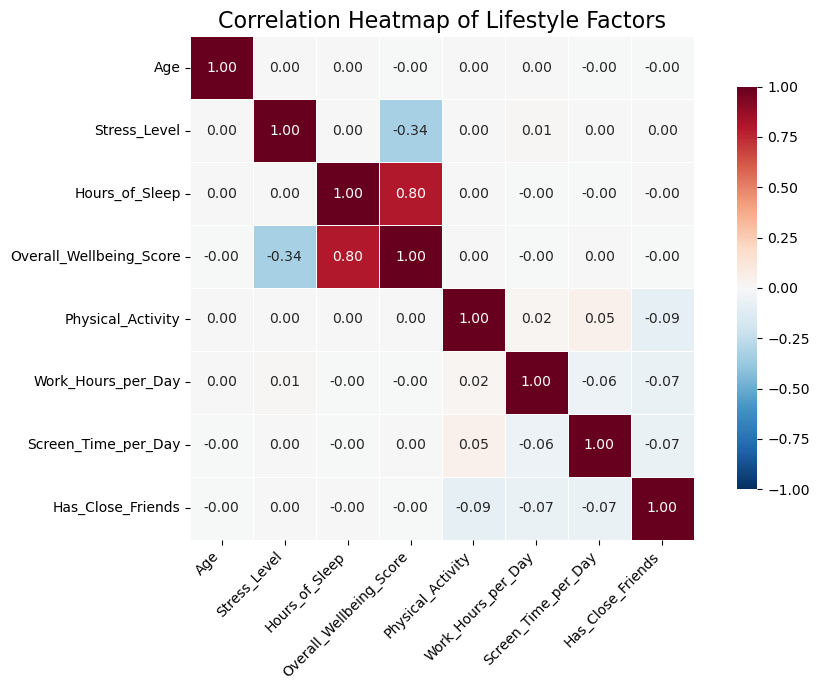

In [15]:
if "Person_ID" in df.columns:
    df = df.drop(columns=["Person_ID"])

# Compute correlation helps identify the relationship between variables
#It helps understand which features influence mental health the most.
corr = df.corr(numeric_only=True)

# Create figure
plt.figure(figsize=(10,7))

# Better heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Heatmap of Lifestyle Factors", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [11]:
#Feature Selection
X = df[["Age", "Gender", "Stress_Level", "Hours_of_Sleep"]]
y = df["Wellbeing_Category"]


In [13]:
#Encoding Categorical Data(cannot understand text)
X["Gender"] = X["Gender"].map({"Male":0, "Female":1})

le = LabelEncoder()
y = le.fit_transform(y)


C:\Users\hp\AppData\Local\Temp\ipykernel_34224\1645758396.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Gender"] = X["Gender"].map({"Male":0, "Female":1})


In [15]:
#Feature scaling standardizes the values so that all features have similar ranges.
#This improves model performance
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [17]:
#Training data trains the model, while testing data evaluates performance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [19]:
#If the dataset is imbalanced, class weights help the model give equal importance to all classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))


In [21]:
#Building the ANN Model
model = Sequential()

model.add(Dense(128, activation='relu', input_dim=4))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
#This prevents overfitting and unnecessary training
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


In [25]:
#Model Training
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7332 - loss: 0.6121 - val_accuracy: 0.8385 - val_loss: 0.4512
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8344 - loss: 0.3887 - val_accuracy: 0.9533 - val_loss: 0.2055
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8621 - loss: 0.3338 - val_accuracy: 0.9733 - val_loss: 0.1344
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8674 - loss: 0.3344 - val_accuracy: 0.9586 - val_loss: 0.1309
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8942 - loss: 0.2824 - val_accuracy: 0.9840 - val_loss: 0.1005
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8875 - loss: 0.2937 - val_accuracy: 0.9706 - val_loss: 0.1190
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8891 - loss: 0.2817 - val_accuracy: 0.9666 - val_loss: 0.1059
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9018 - loss: 0.2450 - val_accu

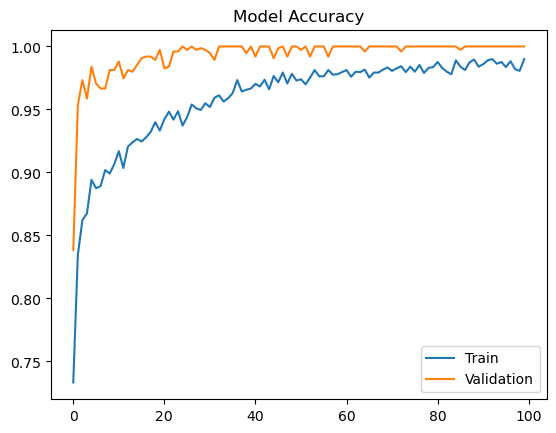

In [27]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


In [29]:
#The trained model predicts wellbeing categories for the test dataset
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


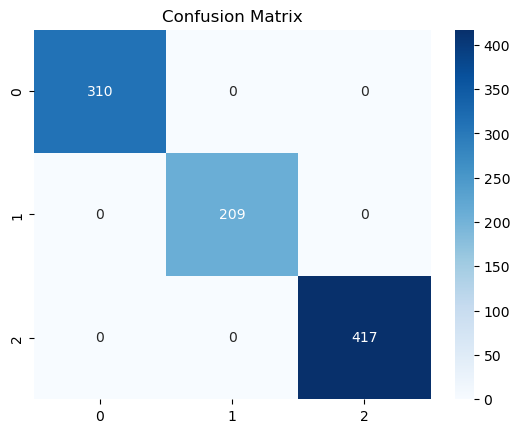

In [31]:
#Confusion matrix evaluates classification performance
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


In [33]:
#Evaluation Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       310
           1       1.00      1.00      1.00       209
           2       1.00      1.00      1.00       417

    accuracy                           1.00       936
   macro avg       1.00      1.00      1.00       936
weighted avg       1.00      1.00      1.00       936



In [35]:
#Saving the Model
import joblib

model.save("wellbeing_model.h5")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")


['label_encoder.pkl']